In this next iteration, please add a Patient process that continues into the pathway (as described in the attached flow diagram). Model parameters are given below. These parameters replicate the base scenario, i.e. with current levels of demand.  Scenarios investigating increased demand multiply the mean arrivals rates by the appropriate factor.  To exclude a particular patient group the mean inter-arrival time for that group is multiplied by a large number such that no arrivals will occur in the modelled time horizon. 
Table S2: Acute Length of stay parameters
				Percentiles
	Mean	Stdev	Median	5th	95th	25th	75th
Strokes – No ESD	7.4	8.6	4.0	1.0	23.0	2.0	9.0
Strokes – ESD	4.6	4.8	3.0	1.0	11.0	2.0	6.0
Stroke – Mortality	7.0	8.7	4.0	0.5	22.0	2.0	8.0
TIA	1.8	2.3	1.0	0.5	4.0	1.0	2.0
Complex-neurological	4.0	5.0	2.0	0.5	13.6	1.0	5.0
Other	3.8	5.2	2.0	0.5	12.1	1.0	5.0
All distributions modelled as lognormal.

Table S2: Rehabilitation length of stay parameters
				Percentiles
	Mean	Stdev	Median	5th	95th	25th	75th
Strokes - No ESD	28.4	27.2	20.0	3.0	86.9	9.0	38.0
Strokes - ESD	30.3	23.1	22.0	6.0	78.0	13.8	44.0
Complex-neurological	27.6	28.4	18.0	2.5	88.5	8.0	36.0
Other	16.1	14.1	11.5	1.0	43.0	5.8	24.3
TIA	18.7	23.5	11.0	1.1	41.6	5.5	28.0
All distributions modelled as lognormal.
 
Table S3: Patient transfer matrix from acute stroke unit
Destination	Stroke	TIA	Complex-neurological	Other
Rehab	24%	1%	11%	5%
ESD	13%	1%	5%	10%
Other*	63%	98%	84%	85%
*Other includes any destination other than rehab or ESD.  For example own home, care home or mortality. 

Table S4: Patient transfer matrix from inpatient rehabilitation ward
	Stroke	TIA	Complex-neurological	Other
ESD	40%	0%	9%	13%
Other	60%	100%	91%	88%
*Other includes any destination other than ESD.  



In [4]:
"""
Stroke pathway DES (Iteration 2): arrivals + patient flow

Python: 3.11
SimPy:  4.1.1

Modelled pathway
----------------
External arrivals -> Acute ward -> {Rehab, ESD, Other}
Optional direct transfers from elsewhere -> Rehab -> {ESD, Other}

Notes
-----
1. Acute and rehab capacities were not provided in the prompt, so they are
   scenario parameters with large defaults. Replace them with paper values.

2. The diagram includes "transfer from elsewhere" into rehab, but no
   inter-arrival parameters were supplied, so that stream is disabled by default.

3. For stroke acute LOS:
   - if acute destination is ESD -> use "stroke_esd"
   - otherwise -> use "stroke_no_esd"
   because no mortality split within "other" was supplied.

4. All LOS distributions are modelled as lognormal and parameterised here
   by mean and standard deviation from the supplied tables.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Optional, Sequence

import math
import simpy
import numpy as np


# ============================================================
# Trace utility
# ============================================================

TRACE = False  # set True to print trace output


def trace(msg: str) -> None:
    """Conditionally print trace messages."""
    if TRACE:
        print(msg)


# ============================================================
# Distribution classes
# ============================================================

class Distribution:
    """Base class for seedable distributions."""

    def __init__(self, random_seed: Optional[int] = None) -> None:
        self.rng = np.random.default_rng(random_seed)


class Exponential(Distribution):
    """Exponential distribution parameterised by mean."""

    def __init__(self, mean: float, random_seed: Optional[int] = None) -> None:
        if mean <= 0:
            raise ValueError("Exponential mean must be > 0.")
        super().__init__(random_seed=random_seed)
        self.mean = float(mean)

    def sample(self) -> float:
        return float(self.rng.exponential(scale=self.mean))


class Lognormal(Distribution):
    """
    Lognormal distribution parameterised by mu and sigma of the
    underlying normal distribution.
    """

    def __init__(self, mu: float, sigma: float, random_seed: Optional[int] = None) -> None:
        if sigma <= 0:
            raise ValueError("Lognormal sigma must be > 0.")
        super().__init__(random_seed=random_seed)
        self.mu = float(mu)
        self.sigma = float(sigma)

    def sample(self) -> float:
        return float(self.rng.lognormal(mean=self.mu, sigma=self.sigma))

    @classmethod
    def from_mean_sd(
        cls,
        mean: float,
        sd: float,
        random_seed: Optional[int] = None,
    ) -> "Lognormal":
        """
        Build a lognormal distribution from arithmetic mean and standard deviation.

        If X ~ Lognormal(mu, sigma), then:
            sigma^2 = ln(1 + (sd^2 / mean^2))
            mu      = ln(mean) - sigma^2 / 2
        """
        if mean <= 0:
            raise ValueError("Lognormal mean must be > 0.")
        if sd <= 0:
            raise ValueError("Lognormal sd must be > 0.")

        variance = sd ** 2
        sigma_sq = math.log(1.0 + variance / (mean ** 2))
        sigma = math.sqrt(sigma_sq)
        mu = math.log(mean) - 0.5 * sigma_sq
        return cls(mu=mu, sigma=sigma, random_seed=random_seed)


# ============================================================
# Data model
# ============================================================

@dataclass
class Patient:
    id: int
    category: str
    arrival_time: float
    source: str = "external"

    acute_queue_enter_time: Optional[float] = None
    acute_start_time: Optional[float] = None
    acute_end_time: Optional[float] = None

    rehab_queue_enter_time: Optional[float] = None
    rehab_start_time: Optional[float] = None
    rehab_end_time: Optional[float] = None

    final_destination: Optional[str] = None


class IdCounter:
    """Simple incrementing ID generator."""

    def __init__(self, start: int = 1) -> None:
        self._next = start

    def next_id(self) -> int:
        value = self._next
        self._next += 1
        return value


# ============================================================
# Scenario
# ============================================================

@dataclass
class Scenario:
    """
    Container for all model parameters.

    Base-case demand values are hard coded via defaults.
    """

    random_seed: int = 42

    # Main patient groups
    categories: tuple[str, ...] = ("stroke", "tia", "complex_neuro", "other")

    # Base-period counts (for reference)
    base_period_counts: dict[str, int] = field(default_factory=lambda: {
        "stroke": 1320,
        "tia": 158,
        "complex_neuro": 456,
        "other": 510,
    })

    # Base-case mean inter-arrival times in days
    mean_iat_days: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.2,
        "tia": 9.3,
        "complex_neuro": 3.6,
        "other": 3.2,
    })

    # Demand multipliers applied to ARRIVAL RATES
    # effective mean IAT = base mean IAT / demand_multiplier
    demand_multipliers: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.0,
        "tia": 1.0,
        "complex_neuro": 1.0,
        "other": 1.0,
    })

    # To exclude a group, multiply its mean IAT by a very large number
    exclusion_multipliers: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.0,
        "tia": 1.0,
        "complex_neuro": 1.0,
        "other": 1.0,
    })

    # Ward capacities
    # Replace these with paper/base-case values when available.
    acute_capacity: int = 999999
    rehab_capacity: int = 999999

    # Optional stream: transfers from elsewhere directly into rehab
    # Disabled by default because no parameters were supplied.
    enable_transfer_from_elsewhere: bool = False
    transfer_from_elsewhere_mean_iat_days: Optional[float] = None
    transfer_from_elsewhere_category_probs: dict[str, float] = field(default_factory=lambda: {
        "stroke": 0.0,
        "tia": 0.0,
        "complex_neuro": 0.0,
        "other": 0.0,
    })

    # Acute LOS parameters (mean, sd), all lognormal
    acute_los_mean_sd: dict[str, tuple[float, float]] = field(default_factory=lambda: {
        "stroke_no_esd": (7.4, 8.6),
        "stroke_esd": (4.6, 4.8),
        "stroke_mortality": (7.0, 8.7),  # not used in this version unless later extended
        "tia": (1.8, 2.3),
        "complex_neuro": (4.0, 5.0),
        "other": (3.8, 5.2),
    })

    # Rehab LOS parameters (mean, sd), all lognormal
    rehab_los_mean_sd: dict[str, tuple[float, float]] = field(default_factory=lambda: {
        "stroke_no_esd": (28.4, 27.2),
        "stroke_esd": (30.3, 23.1),
        "complex_neuro": (27.6, 28.4),
        "other": (16.1, 14.1),
        "tia": (18.7, 23.5),
    })

    # Acute -> destination probabilities
    acute_transfer_probs: dict[str, dict[str, float]] = field(default_factory=lambda: {
        "stroke": {"rehab": 0.24, "esd": 0.13, "other": 0.63},
        "tia": {"rehab": 0.01, "esd": 0.01, "other": 0.98},
        "complex_neuro": {"rehab": 0.11, "esd": 0.05, "other": 0.84},
        "other": {"rehab": 0.05, "esd": 0.10, "other": 0.85},
    })

    # Rehab -> destination probabilities
    rehab_transfer_probs: dict[str, dict[str, float]] = field(default_factory=lambda: {
        "stroke": {"esd": 0.40, "other": 0.60},
        "tia": {"esd": 0.00, "other": 1.00},
        "complex_neuro": {"esd": 0.09, "other": 0.91},
        "other": {"esd": 0.13, "other": 0.88},  # sums to 1.01 in supplied table due to rounding
    })

    def __post_init__(self) -> None:
        category_set = set(self.categories)

        for mapping_name, mapping in [
            ("base_period_counts", self.base_period_counts),
            ("mean_iat_days", self.mean_iat_days),
            ("demand_multipliers", self.demand_multipliers),
            ("exclusion_multipliers", self.exclusion_multipliers),
            ("acute_transfer_probs", self.acute_transfer_probs),
            ("rehab_transfer_probs", self.rehab_transfer_probs),
            ("transfer_from_elsewhere_category_probs", self.transfer_from_elsewhere_category_probs),
        ]:
            missing = category_set - set(mapping)
            extra = set(mapping) - category_set
            if missing or extra:
                raise ValueError(
                    f"{mapping_name} keys mismatch. missing={missing}, extra={extra}"
                )

        if self.acute_capacity <= 0:
            raise ValueError("acute_capacity must be > 0")
        if self.rehab_capacity <= 0:
            raise ValueError("rehab_capacity must be > 0")

        for cat in self.categories:
            if self.mean_iat_days[cat] <= 0:
                raise ValueError(f"mean_iat_days[{cat}] must be > 0")
            if self.demand_multipliers[cat] <= 0:
                raise ValueError(f"demand_multipliers[{cat}] must be > 0")
            if self.exclusion_multipliers[cat] <= 0:
                raise ValueError(f"exclusion_multipliers[{cat}] must be > 0")

        # Normalise slight rounding errors in transfer matrices
        for name, matrix in [
            ("acute_transfer_probs", self.acute_transfer_probs),
            ("rehab_transfer_probs", self.rehab_transfer_probs),
        ]:
            for cat, probs in matrix.items():
                total = sum(probs.values())
                if total <= 0:
                    raise ValueError(f"{name}[{cat}] probabilities must sum to > 0")
                if abs(total - 1.0) > 1e-9:
                    for k in probs:
                        probs[k] = probs[k] / total

        # Normalise transfer-from-elsewhere category probabilities if enabled
        if self.enable_transfer_from_elsewhere:
            if (
                self.transfer_from_elsewhere_mean_iat_days is None
                or self.transfer_from_elsewhere_mean_iat_days <= 0
            ):
                raise ValueError(
                    "transfer_from_elsewhere_mean_iat_days must be provided and > 0 "
                    "when enable_transfer_from_elsewhere=True"
                )
            total = sum(self.transfer_from_elsewhere_category_probs.values())
            if total <= 0:
                raise ValueError(
                    "transfer_from_elsewhere_category_probs must sum to > 0 "
                    "when enable_transfer_from_elsewhere=True"
                )
            for k in self.transfer_from_elsewhere_category_probs:
                self.transfer_from_elsewhere_category_probs[k] /= total

    def effective_mean_iat(self, category: str) -> float:
        """
        Effective mean inter-arrival time after applying:
        - demand multiplier to ARRIVAL RATE
        - exclusion multiplier to mean IAT

        If arrival rate is multiplied by f, mean IAT is divided by f.
        """
        base = self.mean_iat_days[category]
        demand_factor = self.demand_multipliers[category]
        exclusion_factor = self.exclusion_multipliers[category]
        return (base / demand_factor) * exclusion_factor


# ============================================================
# Utility sampling functions
# ============================================================

def sample_from_probs(rng: np.random.Generator, probs: dict[str, float]) -> str:
    """Sample a key from a probability dictionary."""
    labels = list(probs.keys())
    p = np.array(list(probs.values()), dtype=float)
    p = p / p.sum()
    return str(rng.choice(labels, p=p))


# ============================================================
# Model class
# ============================================================

class StrokePathwayModel:
    """SimPy model container."""

    def __init__(self, scenario: Scenario) -> None:
        self.scenario = scenario
        self.env = simpy.Environment()

        # Resources
        self.acute_beds = simpy.Resource(self.env, capacity=scenario.acute_capacity)
        self.rehab_beds = simpy.Resource(self.env, capacity=scenario.rehab_capacity)

        # Master RNG
        self.master_rng = np.random.default_rng(scenario.random_seed)

        # Per-category arrival distributions
        self.arrival_dists: dict[str, Exponential] = {}
        for cat in scenario.categories:
            self.arrival_dists[cat] = Exponential(
                mean=scenario.effective_mean_iat(cat),
                random_seed=self._next_seed(),
            )

        # Optional direct rehab arrivals from elsewhere
        self.transfer_from_elsewhere_dist: Optional[Exponential] = None
        if scenario.enable_transfer_from_elsewhere:
            self.transfer_from_elsewhere_dist = Exponential(
                mean=scenario.transfer_from_elsewhere_mean_iat_days,  # type: ignore[arg-type]
                random_seed=self._next_seed(),
            )

        # LOS distributions
        self.acute_los_dists: dict[str, Lognormal] = {
            key: Lognormal.from_mean_sd(mean=m, sd=s, random_seed=self._next_seed())
            for key, (m, s) in scenario.acute_los_mean_sd.items()
        }

        self.rehab_los_dists: dict[str, Lognormal] = {
            key: Lognormal.from_mean_sd(mean=m, sd=s, random_seed=self._next_seed())
            for key, (m, s) in scenario.rehab_los_mean_sd.items()
        }

        # Routing RNG
        self.routing_rng = np.random.default_rng(self._next_seed())

        # Patient tracking
        self.id_counter = IdCounter(start=1)
        self.patients: list[Patient] = []

        # Summary counters
        self.completed_counts: dict[str, int] = {
            "esd": 0,
            "other": 0,
        }
        self.acute_to_counts: dict[str, int] = {
            "rehab": 0,
            "esd": 0,
            "other": 0,
        }
        self.rehab_to_counts: dict[str, int] = {
            "esd": 0,
            "other": 0,
        }

    def _next_seed(self) -> int:
        return int(self.master_rng.integers(0, 2**32 - 1, dtype=np.uint32).item())

    # --------------------------------------------------------
    # Arrival generators
    # --------------------------------------------------------

    def external_arrival_stream(self, category: str, until_days: float):
        """External arrival process for one category."""
        iat_dist = self.arrival_dists[category]

        while True:
            iat = iat_dist.sample()
            yield self.env.timeout(iat)

            if self.env.now >= until_days:
                return

            patient = Patient(
                id=self.id_counter.next_id(),
                category=category,
                arrival_time=float(self.env.now),
                source="external",
            )
            self.patients.append(patient)

            trace(
                f"[t={self.env.now:8.3f}] external arrival "
                f"id={patient.id:5d} category={patient.category}"
            )

            self.env.process(self.patient_process(patient))

    def transfer_from_elsewhere_stream(self, until_days: float):
        """Optional direct transfer stream into rehab."""
        if self.transfer_from_elsewhere_dist is None:
            return

        while True:
            iat = self.transfer_from_elsewhere_dist.sample()
            yield self.env.timeout(iat)

            if self.env.now >= until_days:
                return

            category = sample_from_probs(
                self.routing_rng,
                self.scenario.transfer_from_elsewhere_category_probs,
            )

            patient = Patient(
                id=self.id_counter.next_id(),
                category=category,
                arrival_time=float(self.env.now),
                source="elsewhere",
            )
            self.patients.append(patient)

            trace(
                f"[t={self.env.now:8.3f}] transfer-from-elsewhere "
                f"id={patient.id:5d} category={patient.category}"
            )

            self.env.process(self.patient_process_from_rehab_entry(patient))

    # --------------------------------------------------------
    # Patient routing logic
    # --------------------------------------------------------

    def choose_acute_destination(self, category: str) -> str:
        return sample_from_probs(self.routing_rng, self.scenario.acute_transfer_probs[category])

    def choose_rehab_destination(self, category: str) -> str:
        return sample_from_probs(self.routing_rng, self.scenario.rehab_transfer_probs[category])

    def sample_acute_los(self, patient: Patient, acute_destination: str) -> float:
        """
        Acute LOS by category.

        Stroke:
        - acute dest ESD  -> stroke_esd
        - otherwise       -> stroke_no_esd

        This is deliberate because the supplied transfer matrix does not separate
        mortality from other destinations.
        """
        if patient.category == "stroke":
            key = "stroke_esd" if acute_destination == "esd" else "stroke_no_esd"
        elif patient.category == "tia":
            key = "tia"
        elif patient.category == "complex_neuro":
            key = "complex_neuro"
        elif patient.category == "other":
            key = "other"
        else:
            raise ValueError(f"Unknown category: {patient.category}")

        return self.acute_los_dists[key].sample()

    def sample_rehab_los(self, patient: Patient, rehab_destination: str) -> float:
        """
        Rehab LOS by category.

        Stroke:
        - rehab dest ESD  -> stroke_esd
        - otherwise       -> stroke_no_esd
        """
        if patient.category == "stroke":
            key = "stroke_esd" if rehab_destination == "esd" else "stroke_no_esd"
        elif patient.category == "tia":
            key = "tia"
        elif patient.category == "complex_neuro":
            key = "complex_neuro"
        elif patient.category == "other":
            key = "other"
        else:
            raise ValueError(f"Unknown category: {patient.category}")

        return self.rehab_los_dists[key].sample()

    def patient_process(self, patient: Patient):
        """Full pathway for a patient entering through acute."""
        # -------------------------
        # Acute ward
        # -------------------------
        patient.acute_queue_enter_time = float(self.env.now)

        with self.acute_beds.request() as req:
            yield req
            patient.acute_start_time = float(self.env.now)

            acute_wait = patient.acute_start_time - patient.acute_queue_enter_time
            acute_destination = self.choose_acute_destination(patient.category)
            acute_los = self.sample_acute_los(patient, acute_destination)

            trace(
                f"[t={self.env.now:8.3f}] acute start "
                f"id={patient.id:5d} cat={patient.category:14s} "
                f"wait={acute_wait:7.3f} dest={acute_destination:5s} "
                f"los={acute_los:7.3f}"
            )

            yield self.env.timeout(acute_los)
            patient.acute_end_time = float(self.env.now)

        self.acute_to_counts[acute_destination] += 1

        trace(
            f"[t={self.env.now:8.3f}] acute end   "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"next={acute_destination}"
        )

        # -------------------------
        # Route after acute
        # -------------------------
        if acute_destination == "rehab":
            yield self.env.process(self.enter_rehab(patient))
        else:
            patient.final_destination = acute_destination
            self.completed_counts[acute_destination] += 1

            trace(
                f"[t={self.env.now:8.3f}] pathway end "
                f"id={patient.id:5d} final={patient.final_destination}"
            )

    def patient_process_from_rehab_entry(self, patient: Patient):
        """Pathway for patients arriving directly into rehab from elsewhere."""
        yield self.env.process(self.enter_rehab(patient))

    def enter_rehab(self, patient: Patient):
        """Rehab ward stay and onward routing."""
        patient.rehab_queue_enter_time = float(self.env.now)

        with self.rehab_beds.request() as req:
            yield req
            patient.rehab_start_time = float(self.env.now)

            rehab_wait = patient.rehab_start_time - patient.rehab_queue_enter_time
            rehab_destination = self.choose_rehab_destination(patient.category)
            rehab_los = self.sample_rehab_los(patient, rehab_destination)

            trace(
                f"[t={self.env.now:8.3f}] rehab start "
                f"id={patient.id:5d} cat={patient.category:14s} "
                f"wait={rehab_wait:7.3f} dest={rehab_destination:5s} "
                f"los={rehab_los:7.3f}"
            )

            yield self.env.timeout(rehab_los)
            patient.rehab_end_time = float(self.env.now)

        self.rehab_to_counts[rehab_destination] += 1
        patient.final_destination = rehab_destination
        self.completed_counts[rehab_destination] += 1

        trace(
            f"[t={self.env.now:8.3f}] rehab end   "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"final={patient.final_destination}"
        )

    # --------------------------------------------------------
    # Run
    # --------------------------------------------------------

    def run(self, sim_days: float, categories: Optional[Sequence[str]] = None) -> None:
        """Run the model."""
        if sim_days <= 0:
            raise ValueError("sim_days must be > 0")

        selected = list(categories) if categories is not None else list(self.scenario.categories)

        unknown = sorted(set(selected) - set(self.scenario.categories))
        if unknown:
            raise ValueError(
                f"Unknown categories: {unknown}. Valid categories are {list(self.scenario.categories)}"
            )

        for cat in selected:
            self.env.process(self.external_arrival_stream(category=cat, until_days=sim_days))

        if self.scenario.enable_transfer_from_elsewhere:
            self.env.process(self.transfer_from_elsewhere_stream(until_days=sim_days))

        trace(f"Starting simulation for {sim_days} days with categories={selected}")
        self.env.run(until=sim_days)
        trace("Simulation finished.")


# ============================================================
# Convenience functions
# ============================================================

def run_simulation(
    sim_days: float,
    scenario: Optional[Scenario] = None,
    categories: Optional[Sequence[str]] = None,
) -> StrokePathwayModel:
    """Create, run, and return a model instance."""
    sc = scenario or Scenario()
    model = StrokePathwayModel(sc)
    model.run(sim_days=sim_days, categories=categories)
    return model


def summarise_patient_counts(model: StrokePathwayModel) -> dict[str, int]:
    """Count arrivals by category."""
    counts = {c: 0 for c in model.scenario.categories}
    for patient in model.patients:
        counts[patient.category] += 1
    return counts


def summarise_completed_destinations(model: StrokePathwayModel) -> dict[str, int]:
    """Return final completed destination counts."""
    return dict(model.completed_counts)


def mean_wait_time(values: list[float]) -> float:
    return sum(values) / len(values) if values else 0.0


def summarise_waits(model: StrokePathwayModel) -> dict[str, float]:
    acute_waits = []
    rehab_waits = []

    for p in model.patients:
        if p.acute_queue_enter_time is not None and p.acute_start_time is not None:
            acute_waits.append(p.acute_start_time - p.acute_queue_enter_time)
        if p.rehab_queue_enter_time is not None and p.rehab_start_time is not None:
            rehab_waits.append(p.rehab_start_time - p.rehab_queue_enter_time)

    return {
        "mean_acute_wait_days": mean_wait_time(acute_waits),
        "mean_rehab_wait_days": mean_wait_time(rehab_waits),
    }


# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    sc = Scenario(
        random_seed=42,
        acute_capacity=12,  # replace with base-case value
        rehab_capacity=12,  # replace with base-case value
    )

    model = run_simulation(sim_days=365.0, scenario=sc)

    arrival_counts = summarise_patient_counts(model)
    final_counts = summarise_completed_destinations(model)
    waits = summarise_waits(model)

    total = sum(arrival_counts.values())

    print(f"Total arrivals over 365 days: {total}")
    print("\nArrivals by category:")
    for cat, n in arrival_counts.items():
        print(f"  {cat:14s}: {n:5d}")

    print("\nAcute -> destination counts:")
    for dest, n in model.acute_to_counts.items():
        print(f"  {dest:5s}: {n:5d}")

    print("\nRehab -> destination counts:")
    for dest, n in model.rehab_to_counts.items():
        print(f"  {dest:5s}: {n:5d}")

    print("\nCompleted final destinations:")
    for dest, n in final_counts.items():
        print(f"  {dest:5s}: {n:5d}")

    print("\nMean waits:")
    for k, v in waits.items():
        print(f"  {k:22s}: {v:8.3f}")

Total arrivals over 365 days: 597

Arrivals by category:
  stroke        :   322
  tia           :    37
  complex_neuro :   119
  other         :   119

Acute -> destination counts:
  rehab:    94
  esd  :    56
  other:   438

Rehab -> destination counts:
  esd  :    33
  other:    54

Completed final destinations:
  esd  :    89
  other:   492

Mean waits:
  mean_acute_wait_days  :    0.369
  mean_rehab_wait_days  :    0.402


Monks et al's model estimates the probability that a patient can-
not be immediately admitted to the acute unit, commu-
nity rehabilitation unit or ESD. They call this estimate the
probability of delay or for shorthand p(delay). For each
scenario investigated they estimate p(delay) for a range of
bed numbers and construct a stepped trade-off curve
(see attached chart for an example). The reciprocal (1/p(delay))
provides a quantity that is easily understood by clinicians
and managers. For example, p(delay) = 0.02 means that 1
in every 50 patients will experience some delay in admis-
sion or transfer.  Please can you amend the code to produce this outcome measure, producing a chart similar to the attached chart.

Please consolidate this into a single clean python module suitable for pasting into a jupyter notebook.

Single-run summary
------------------
Arrivals by category:
  stroke        :   322
  tia           :    37
  complex_neuro :   119
  other         :   119

Delay measures:
  p_delay_acute   :   0.6365   1 in every 1.6 patients delayed
  p_delay_rehab   :   0.4894   1 in every 2.0 patients delayed
  p_delay_overall :   0.6231   1 in every 1.6 patients delayed

Mean waits:
  mean_acute_wait_days  :    2.192
  mean_rehab_wait_days  :    6.689

Acute bed sweep:
acute_beds= 1  p_delay_acute=0.9994  1 in every 1.0 patients delayed
acute_beds= 2  p_delay_acute=0.9985  1 in every 1.0 patients delayed
acute_beds= 3  p_delay_acute=0.9977  1 in every 1.0 patients delayed
acute_beds= 4  p_delay_acute=0.9964  1 in every 1.0 patients delayed
acute_beds= 5  p_delay_acute=0.9945  1 in every 1.0 patients delayed
acute_beds= 6  p_delay_acute=0.9904  1 in every 1.0 patients delayed
acute_beds= 7  p_delay_acute=0.9833  1 in every 1.0 patients delayed
acute_beds= 8  p_delay_acute=0.9525  1 in every 1.0 pa

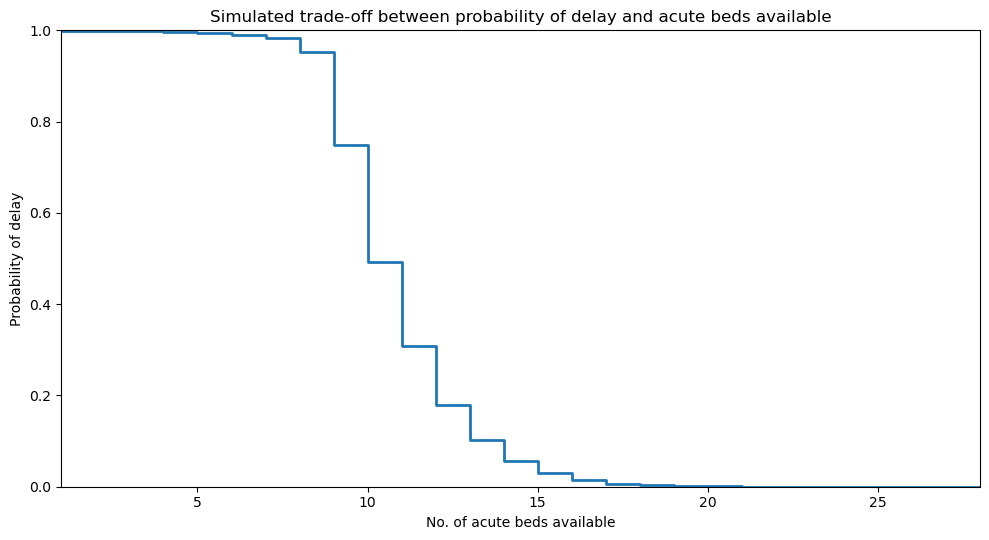

In [9]:
"""
stroke_pathway_sim.py

Discrete-event simulation of a hospital stroke pathway using SimPy.

Python: 3.11
SimPy:  4.1.1

Model scope
-----------
- External arrivals in 4 categories:
    * stroke
    * tia
    * complex_neuro
    * other

- Pathway:
    external arrivals -> acute ward -> {rehab, esd, other}
    optional transfer-from-elsewhere -> rehab -> {esd, other}

- Acute and rehab lengths of stay are modelled as lognormal.

- Delay outcome:
    p(delay) = probability that a patient cannot be immediately admitted or transferred
    into the modelled unit when they attempt entry.

Implemented delay measures:
- p_delay_acute:
    Probability that a patient attempting acute admission is delayed.
- p_delay_rehab:
    Probability that a patient attempting rehab transfer/admission is delayed.
- p_delay_overall:
    Probability that a patient experiences any delay anywhere in the modelled pathway.

Notes
-----
1. ESD is represented here as a terminal destination, not a capacity-constrained service.
   Therefore this version does NOT yet estimate delay into ESD itself.

2. The diagram includes "transfer from elsewhere" into rehab, but no parameters for that
   stream were supplied, so it is disabled by default.

3. Acute stroke LOS supplied in the source distinguishes:
      - stroke_no_esd
      - stroke_esd
      - stroke_mortality
   but the acute transfer matrix only routes to:
      - rehab
      - esd
      - other
   without splitting "other" into mortality vs non-mortality.
   Therefore, in this implementation:
      - if acute destination is ESD -> use stroke_esd LOS
      - otherwise                  -> use stroke_no_esd LOS

4. Scenarios with increased demand multiply arrival rates by a factor f.
   Since rate = 1 / mean_interarrival, the effective mean inter-arrival time is divided by f.

5. To exclude a category, multiply its mean inter-arrival time by a very large number
   using exclusion_multipliers[category], e.g. 1e9.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Optional, Sequence, Iterable
import math

import matplotlib.pyplot as plt
import numpy as np
import simpy


# ============================================================
# Trace utility
# ============================================================

TRACE = False


def trace(msg: str) -> None:
    """Conditionally print trace messages to the console."""
    if TRACE:
        print(msg)


# ============================================================
# Distribution classes
# ============================================================

class Distribution:
    """Base class for seedable distributions."""

    def __init__(self, random_seed: Optional[int] = None) -> None:
        self.rng = np.random.default_rng(random_seed)


class Exponential(Distribution):
    """Exponential distribution parameterised by arithmetic mean."""

    def __init__(self, mean: float, random_seed: Optional[int] = None) -> None:
        if mean <= 0:
            raise ValueError("Exponential mean must be > 0.")
        super().__init__(random_seed=random_seed)
        self.mean = float(mean)

    def sample(self) -> float:
        """Sample one value."""
        return float(self.rng.exponential(scale=self.mean))


class Lognormal(Distribution):
    """
    Lognormal distribution parameterised by mu and sigma of the underlying normal.
    """

    def __init__(self, mu: float, sigma: float, random_seed: Optional[int] = None) -> None:
        if sigma <= 0:
            raise ValueError("Lognormal sigma must be > 0.")
        super().__init__(random_seed=random_seed)
        self.mu = float(mu)
        self.sigma = float(sigma)

    def sample(self) -> float:
        """Sample one value."""
        return float(self.rng.lognormal(mean=self.mu, sigma=self.sigma))

    @classmethod
    def from_mean_sd(
        cls,
        mean: float,
        sd: float,
        random_seed: Optional[int] = None,
    ) -> "Lognormal":
        """
        Construct a lognormal distribution from arithmetic mean and standard deviation.

        For X ~ Lognormal(mu, sigma):
            sigma^2 = ln(1 + sd^2 / mean^2)
            mu      = ln(mean) - sigma^2 / 2
        """
        if mean <= 0:
            raise ValueError("Lognormal mean must be > 0.")
        if sd <= 0:
            raise ValueError("Lognormal sd must be > 0.")

        variance = sd ** 2
        sigma_sq = math.log(1.0 + variance / (mean ** 2))
        sigma = math.sqrt(sigma_sq)
        mu = math.log(mean) - 0.5 * sigma_sq
        return cls(mu=mu, sigma=sigma, random_seed=random_seed)


# ============================================================
# Data model
# ============================================================

@dataclass
class Patient:
    """Represents one patient flowing through the model."""
    id: int
    category: str
    arrival_time: float
    source: str = "external"

    acute_queue_enter_time: Optional[float] = None
    acute_start_time: Optional[float] = None
    acute_end_time: Optional[float] = None

    rehab_queue_enter_time: Optional[float] = None
    rehab_start_time: Optional[float] = None
    rehab_end_time: Optional[float] = None

    final_destination: Optional[str] = None

    delayed_in_acute: bool = False
    delayed_in_rehab: bool = False
    delayed_anywhere: bool = False


class IdCounter:
    """Simple incrementing patient ID generator."""

    def __init__(self, start: int = 1) -> None:
        self._next = start

    def next_id(self) -> int:
        value = self._next
        self._next += 1
        return value


# ============================================================
# Scenario container
# ============================================================

@dataclass
class Scenario:
    """
    Container for all model parameters.

    Defaults represent the base-case scenario.
    """

    random_seed: int = 42

    categories: tuple[str, ...] = ("stroke", "tia", "complex_neuro", "other")

    base_period_counts: dict[str, int] = field(default_factory=lambda: {
        "stroke": 1320,
        "tia": 158,
        "complex_neuro": 456,
        "other": 510,
    })

    # Base-case mean inter-arrival times in days
    mean_iat_days: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.2,
        "tia": 9.3,
        "complex_neuro": 3.6,
        "other": 3.2,
    })

    # Demand multiplier applied to arrival rate.
    # effective mean IAT = base mean IAT / demand_multiplier
    demand_multipliers: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.0,
        "tia": 1.0,
        "complex_neuro": 1.0,
        "other": 1.0,
    })

    # To exclude a group, multiply mean IAT by a very large number.
    exclusion_multipliers: dict[str, float] = field(default_factory=lambda: {
        "stroke": 1.0,
        "tia": 1.0,
        "complex_neuro": 1.0,
        "other": 1.0,
    })

    # Capacities: replace with paper/base-case values when known
    acute_capacity: int = 10
    rehab_capacity: int = 12

    # Optional stream: direct transfers from elsewhere into rehab
    enable_transfer_from_elsewhere: bool = False
    transfer_from_elsewhere_mean_iat_days: Optional[float] = None
    transfer_from_elsewhere_category_probs: dict[str, float] = field(default_factory=lambda: {
        "stroke": 0.0,
        "tia": 0.0,
        "complex_neuro": 0.0,
        "other": 0.0,
    })

    # Acute LOS parameters: arithmetic mean, sd
    acute_los_mean_sd: dict[str, tuple[float, float]] = field(default_factory=lambda: {
        "stroke_no_esd": (7.4, 8.6),
        "stroke_esd": (4.6, 4.8),
        "stroke_mortality": (7.0, 8.7),  # currently unused
        "tia": (1.8, 2.3),
        "complex_neuro": (4.0, 5.0),
        "other": (3.8, 5.2),
    })

    # Rehab LOS parameters: arithmetic mean, sd
    rehab_los_mean_sd: dict[str, tuple[float, float]] = field(default_factory=lambda: {
        "stroke_no_esd": (28.4, 27.2),
        "stroke_esd": (30.3, 23.1),
        "complex_neuro": (27.6, 28.4),
        "other": (16.1, 14.1),
        "tia": (18.7, 23.5),
    })

    # Acute -> destination transfer probabilities
    acute_transfer_probs: dict[str, dict[str, float]] = field(default_factory=lambda: {
        "stroke": {"rehab": 0.24, "esd": 0.13, "other": 0.63},
        "tia": {"rehab": 0.01, "esd": 0.01, "other": 0.98},
        "complex_neuro": {"rehab": 0.11, "esd": 0.05, "other": 0.84},
        "other": {"rehab": 0.05, "esd": 0.10, "other": 0.85},
    })

    # Rehab -> destination transfer probabilities
    rehab_transfer_probs: dict[str, dict[str, float]] = field(default_factory=lambda: {
        "stroke": {"esd": 0.40, "other": 0.60},
        "tia": {"esd": 0.00, "other": 1.00},
        "complex_neuro": {"esd": 0.09, "other": 0.91},
        "other": {"esd": 0.13, "other": 0.88},  # 1.01 due to rounding; normalised in __post_init__
    })

    def __post_init__(self) -> None:
        category_set = set(self.categories)

        for mapping_name, mapping in [
            ("base_period_counts", self.base_period_counts),
            ("mean_iat_days", self.mean_iat_days),
            ("demand_multipliers", self.demand_multipliers),
            ("exclusion_multipliers", self.exclusion_multipliers),
            ("acute_transfer_probs", self.acute_transfer_probs),
            ("rehab_transfer_probs", self.rehab_transfer_probs),
            ("transfer_from_elsewhere_category_probs", self.transfer_from_elsewhere_category_probs),
        ]:
            missing = category_set - set(mapping)
            extra = set(mapping) - category_set
            if missing or extra:
                raise ValueError(
                    f"{mapping_name} keys mismatch. missing={missing}, extra={extra}"
                )

        if self.acute_capacity <= 0:
            raise ValueError("acute_capacity must be > 0.")
        if self.rehab_capacity <= 0:
            raise ValueError("rehab_capacity must be > 0.")

        for cat in self.categories:
            if self.mean_iat_days[cat] <= 0:
                raise ValueError(f"mean_iat_days[{cat}] must be > 0.")
            if self.demand_multipliers[cat] <= 0:
                raise ValueError(f"demand_multipliers[{cat}] must be > 0.")
            if self.exclusion_multipliers[cat] <= 0:
                raise ValueError(f"exclusion_multipliers[{cat}] must be > 0.")

        # Normalise any small rounding discrepancies in transfer matrices
        for name, matrix in [
            ("acute_transfer_probs", self.acute_transfer_probs),
            ("rehab_transfer_probs", self.rehab_transfer_probs),
        ]:
            for cat, probs in matrix.items():
                total = sum(probs.values())
                if total <= 0:
                    raise ValueError(f"{name}[{cat}] probabilities must sum to > 0.")
                if abs(total - 1.0) > 1e-12:
                    for key in probs:
                        probs[key] = probs[key] / total

        if self.enable_transfer_from_elsewhere:
            if (
                self.transfer_from_elsewhere_mean_iat_days is None
                or self.transfer_from_elsewhere_mean_iat_days <= 0
            ):
                raise ValueError(
                    "transfer_from_elsewhere_mean_iat_days must be provided and > 0 "
                    "when enable_transfer_from_elsewhere=True."
                )
            total = sum(self.transfer_from_elsewhere_category_probs.values())
            if total <= 0:
                raise ValueError(
                    "transfer_from_elsewhere_category_probs must sum to > 0 "
                    "when enable_transfer_from_elsewhere=True."
                )
            for key in self.transfer_from_elsewhere_category_probs:
                self.transfer_from_elsewhere_category_probs[key] /= total

    def effective_mean_iat(self, category: str) -> float:
        """
        Return effective mean inter-arrival time after applying:
        - demand multiplier to rate
        - exclusion multiplier to mean IAT
        """
        base = self.mean_iat_days[category]
        demand_factor = self.demand_multipliers[category]
        exclusion_factor = self.exclusion_multipliers[category]
        return (base / demand_factor) * exclusion_factor


# ============================================================
# Utility functions
# ============================================================

def sample_from_probs(rng: np.random.Generator, probs: dict[str, float]) -> str:
    """Sample one key from a probability dictionary."""
    labels = list(probs.keys())
    p = np.array(list(probs.values()), dtype=float)
    p = p / p.sum()
    return str(rng.choice(labels, p=p))


def safe_div(numerator: int, denominator: int) -> float:
    """Safe division returning 0.0 if denominator is zero."""
    return numerator / denominator if denominator > 0 else 0.0


def reciprocal_delay_text(p_delay: float) -> str:
    """
    Format p(delay) as a clinician-friendly reciprocal.

    Example:
        p_delay = 0.02 -> '1 in every 50.0 patients delayed'
    """
    if p_delay <= 0:
        return "No delays observed"
    return f"1 in every {1.0 / p_delay:.1f} patients delayed"


# ============================================================
# Main model class
# ============================================================

class StrokePathwayModel:
    """SimPy model container."""

    def __init__(self, scenario: Scenario) -> None:
        self.scenario = scenario
        self.env = simpy.Environment()

        # Capacity-constrained resources
        self.acute_beds = simpy.Resource(self.env, capacity=scenario.acute_capacity)
        self.rehab_beds = simpy.Resource(self.env, capacity=scenario.rehab_capacity)

        # Master RNG used to derive independent seeds
        self.master_rng = np.random.default_rng(scenario.random_seed)

        # One arrival distribution per category
        self.arrival_dists: dict[str, Exponential] = {
            cat: Exponential(
                mean=scenario.effective_mean_iat(cat),
                random_seed=self._next_seed(),
            )
            for cat in scenario.categories
        }

        self.transfer_from_elsewhere_dist: Optional[Exponential] = None
        if scenario.enable_transfer_from_elsewhere:
            self.transfer_from_elsewhere_dist = Exponential(
                mean=scenario.transfer_from_elsewhere_mean_iat_days,  # type: ignore[arg-type]
                random_seed=self._next_seed(),
            )

        # LOS distributions
        self.acute_los_dists: dict[str, Lognormal] = {
            key: Lognormal.from_mean_sd(mean=m, sd=s, random_seed=self._next_seed())
            for key, (m, s) in scenario.acute_los_mean_sd.items()
        }
        self.rehab_los_dists: dict[str, Lognormal] = {
            key: Lognormal.from_mean_sd(mean=m, sd=s, random_seed=self._next_seed())
            for key, (m, s) in scenario.rehab_los_mean_sd.items()
        }

        # Routing RNG
        self.routing_rng = np.random.default_rng(self._next_seed())

        # Entity tracking
        self.id_counter = IdCounter(start=1)
        self.patients: list[Patient] = []

        # Summary counters
        self.completed_counts: dict[str, int] = {"esd": 0, "other": 0}
        self.acute_to_counts: dict[str, int] = {"rehab": 0, "esd": 0, "other": 0}
        self.rehab_to_counts: dict[str, int] = {"esd": 0, "other": 0}

        # Delay counters
        self.delay_stats = {
            "acute": {"attempts": 0, "delayed": 0},
            "rehab": {"attempts": 0, "delayed": 0},
            "overall": {
                "patients_with_any_attempt": 0,
                "patients_delayed_anywhere": 0,
            },
        }

    def _next_seed(self) -> int:
        """Generate an integer seed from the model's master RNG."""
        return int(self.master_rng.integers(0, 2**32 - 1, dtype=np.uint32).item())

    # --------------------------------------------------------
    # Arrival streams
    # --------------------------------------------------------

    def external_arrival_stream(self, category: str, until_days: float):
        """Generate external arrivals for one patient category."""
        iat_dist = self.arrival_dists[category]

        while True:
            iat = iat_dist.sample()
            yield self.env.timeout(iat)

            if self.env.now >= until_days:
                return

            patient = Patient(
                id=self.id_counter.next_id(),
                category=category,
                arrival_time=float(self.env.now),
                source="external",
            )
            self.patients.append(patient)

            trace(
                f"[t={self.env.now:8.3f}] external arrival "
                f"id={patient.id:5d} category={patient.category}"
            )

            self.env.process(self.patient_process(patient))

    def transfer_from_elsewhere_stream(self, until_days: float):
        """Optional direct transfer stream into rehab."""
        if self.transfer_from_elsewhere_dist is None:
            return

        while True:
            iat = self.transfer_from_elsewhere_dist.sample()
            yield self.env.timeout(iat)

            if self.env.now >= until_days:
                return

            category = sample_from_probs(
                self.routing_rng,
                self.scenario.transfer_from_elsewhere_category_probs,
            )

            patient = Patient(
                id=self.id_counter.next_id(),
                category=category,
                arrival_time=float(self.env.now),
                source="elsewhere",
            )
            self.patients.append(patient)

            trace(
                f"[t={self.env.now:8.3f}] transfer-from-elsewhere "
                f"id={patient.id:5d} category={patient.category}"
            )

            self.env.process(self.patient_process_from_rehab_entry(patient))

    # --------------------------------------------------------
    # Routing logic
    # --------------------------------------------------------

    def choose_acute_destination(self, category: str) -> str:
        """Sample acute destination for a given patient category."""
        return sample_from_probs(self.routing_rng, self.scenario.acute_transfer_probs[category])

    def choose_rehab_destination(self, category: str) -> str:
        """Sample rehab destination for a given patient category."""
        return sample_from_probs(self.routing_rng, self.scenario.rehab_transfer_probs[category])

    def sample_acute_los(self, patient: Patient, acute_destination: str) -> float:
        """
        Sample acute LOS.

        Stroke:
        - if acute destination is ESD -> stroke_esd
        - otherwise                   -> stroke_no_esd
        """
        if patient.category == "stroke":
            key = "stroke_esd" if acute_destination == "esd" else "stroke_no_esd"
        elif patient.category == "tia":
            key = "tia"
        elif patient.category == "complex_neuro":
            key = "complex_neuro"
        elif patient.category == "other":
            key = "other"
        else:
            raise ValueError(f"Unknown category: {patient.category}")

        return self.acute_los_dists[key].sample()

    def sample_rehab_los(self, patient: Patient, rehab_destination: str) -> float:
        """
        Sample rehab LOS.

        Stroke:
        - if rehab destination is ESD -> stroke_esd
        - otherwise                   -> stroke_no_esd
        """
        if patient.category == "stroke":
            key = "stroke_esd" if rehab_destination == "esd" else "stroke_no_esd"
        elif patient.category == "tia":
            key = "tia"
        elif patient.category == "complex_neuro":
            key = "complex_neuro"
        elif patient.category == "other":
            key = "other"
        else:
            raise ValueError(f"Unknown category: {patient.category}")

        return self.rehab_los_dists[key].sample()

    # --------------------------------------------------------
    # Patient processes
    # --------------------------------------------------------

    def patient_process(self, patient: Patient):
        """Full pathway for a patient entering through the acute ward."""
        self.delay_stats["overall"]["patients_with_any_attempt"] += 1

        # Acute entry
        patient.acute_queue_enter_time = float(self.env.now)
        self.delay_stats["acute"]["attempts"] += 1

        req = self.acute_beds.request()

        # Key fix:
        # If the request is not triggered immediately, the patient is delayed.
        if not req.triggered:
            patient.delayed_in_acute = True
            patient.delayed_anywhere = True
            self.delay_stats["acute"]["delayed"] += 1

        yield req
        patient.acute_start_time = float(self.env.now)

        acute_wait = patient.acute_start_time - patient.acute_queue_enter_time
        acute_destination = self.choose_acute_destination(patient.category)
        acute_los = self.sample_acute_los(patient, acute_destination)

        trace(
            f"[t={self.env.now:8.3f}] acute start "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"wait={acute_wait:7.3f} delayed={patient.delayed_in_acute} "
            f"dest={acute_destination:5s} los={acute_los:7.3f}"
        )

        yield self.env.timeout(acute_los)
        patient.acute_end_time = float(self.env.now)

        self.acute_beds.release(req)

        self.acute_to_counts[acute_destination] += 1

        trace(
            f"[t={self.env.now:8.3f}] acute end   "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"next={acute_destination}"
        )

        if acute_destination == "rehab":
            yield self.env.process(self.enter_rehab(patient))
        else:
            patient.final_destination = acute_destination
            self.completed_counts[acute_destination] += 1

            if patient.delayed_anywhere:
                self.delay_stats["overall"]["patients_delayed_anywhere"] += 1

            trace(
                f"[t={self.env.now:8.3f}] pathway end "
                f"id={patient.id:5d} final={patient.final_destination}"
            )

    def patient_process_from_rehab_entry(self, patient: Patient):
        """Pathway for patients arriving directly into rehab from elsewhere."""
        self.delay_stats["overall"]["patients_with_any_attempt"] += 1
        yield self.env.process(self.enter_rehab(patient))

    def enter_rehab(self, patient: Patient):
        """Rehab stay and onward routing."""
        patient.rehab_queue_enter_time = float(self.env.now)
        self.delay_stats["rehab"]["attempts"] += 1

        req = self.rehab_beds.request()

        # Key fix:
        # If the request is not triggered immediately, the patient is delayed.
        if not req.triggered:
            patient.delayed_in_rehab = True
            patient.delayed_anywhere = True
            self.delay_stats["rehab"]["delayed"] += 1

        yield req
        patient.rehab_start_time = float(self.env.now)

        rehab_wait = patient.rehab_start_time - patient.rehab_queue_enter_time
        rehab_destination = self.choose_rehab_destination(patient.category)
        rehab_los = self.sample_rehab_los(patient, rehab_destination)

        trace(
            f"[t={self.env.now:8.3f}] rehab start "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"wait={rehab_wait:7.3f} delayed={patient.delayed_in_rehab} "
            f"dest={rehab_destination:5s} los={rehab_los:7.3f}"
        )

        yield self.env.timeout(rehab_los)
        patient.rehab_end_time = float(self.env.now)

        self.rehab_beds.release(req)

        self.rehab_to_counts[rehab_destination] += 1
        patient.final_destination = rehab_destination
        self.completed_counts[rehab_destination] += 1

        if patient.delayed_anywhere:
            self.delay_stats["overall"]["patients_delayed_anywhere"] += 1

        trace(
            f"[t={self.env.now:8.3f}] rehab end   "
            f"id={patient.id:5d} cat={patient.category:14s} "
            f"final={patient.final_destination}"
        )

    # --------------------------------------------------------
    # Run method
    # --------------------------------------------------------

    def run(self, sim_days: float, categories: Optional[Sequence[str]] = None) -> None:
        """Run the model for the requested simulation horizon."""
        if sim_days <= 0:
            raise ValueError("sim_days must be > 0.")

        selected = list(categories) if categories is not None else list(self.scenario.categories)

        unknown = sorted(set(selected) - set(self.scenario.categories))
        if unknown:
            raise ValueError(
                f"Unknown categories: {unknown}. Valid categories: {list(self.scenario.categories)}"
            )

        for cat in selected:
            self.env.process(self.external_arrival_stream(category=cat, until_days=sim_days))

        if self.scenario.enable_transfer_from_elsewhere:
            self.env.process(self.transfer_from_elsewhere_stream(until_days=sim_days))

        trace(f"Starting simulation for {sim_days} days with categories={selected}")
        self.env.run(until=sim_days)
        trace("Simulation finished.")


# ============================================================
# Convenience functions
# ============================================================

def run_simulation(
    sim_days: float,
    scenario: Optional[Scenario] = None,
    categories: Optional[Sequence[str]] = None,
) -> StrokePathwayModel:
    """Create, run, and return a completed model instance."""
    sc = scenario or Scenario()
    model = StrokePathwayModel(sc)
    model.run(sim_days=sim_days, categories=categories)
    return model


def summarise_patient_counts(model: StrokePathwayModel) -> dict[str, int]:
    """Count arrivals by patient category."""
    counts = {c: 0 for c in model.scenario.categories}
    for patient in model.patients:
        counts[patient.category] += 1
    return counts


def summarise_completed_destinations(model: StrokePathwayModel) -> dict[str, int]:
    """Return completed final destination counts."""
    return dict(model.completed_counts)


def summarise_waits(model: StrokePathwayModel) -> dict[str, float]:
    """Return mean acute and rehab waiting times."""
    acute_waits: list[float] = []
    rehab_waits: list[float] = []

    for p in model.patients:
        if p.acute_queue_enter_time is not None and p.acute_start_time is not None:
            acute_waits.append(p.acute_start_time - p.acute_queue_enter_time)
        if p.rehab_queue_enter_time is not None and p.rehab_start_time is not None:
            rehab_waits.append(p.rehab_start_time - p.rehab_queue_enter_time)

    return {
        "mean_acute_wait_days": float(np.mean(acute_waits)) if acute_waits else 0.0,
        "mean_rehab_wait_days": float(np.mean(rehab_waits)) if rehab_waits else 0.0,
    }


def summarise_p_delay(model: StrokePathwayModel) -> dict[str, float]:
    """
    Return estimated probabilities of delay.

    acute:
        Probability a patient attempting acute admission is delayed.
    rehab:
        Probability a patient attempting rehab admission/transfer is delayed.
    overall:
        Probability a patient experiences any delay anywhere in the modelled pathway.
    """
    acute_attempts = model.delay_stats["acute"]["attempts"]
    acute_delayed = model.delay_stats["acute"]["delayed"]

    rehab_attempts = model.delay_stats["rehab"]["attempts"]
    rehab_delayed = model.delay_stats["rehab"]["delayed"]

    overall_attempts = model.delay_stats["overall"]["patients_with_any_attempt"]
    overall_delayed = model.delay_stats["overall"]["patients_delayed_anywhere"]

    return {
        "p_delay_acute": safe_div(acute_delayed, acute_attempts),
        "p_delay_rehab": safe_div(rehab_delayed, rehab_attempts),
        "p_delay_overall": safe_div(overall_delayed, overall_attempts),
    }


# ============================================================
# Scenario sweep for trade-off curves
# ============================================================

def evaluate_p_delay_over_beds(
    *,
    sim_days: float,
    base_scenario: Scenario,
    acute_bed_range: Sequence[int],
    rehab_beds: Optional[int] = None,
    replications: int = 20,
    categories: Optional[Sequence[str]] = None,
) -> list[dict[str, float]]:
    """
    Sweep across acute bed numbers and estimate p(delay).

    Returns
    -------
    list of dict
        One row per acute bed value containing:
        - acute_beds
        - p_delay_acute
        - p_delay_rehab
        - p_delay_overall
    """
    if replications <= 0:
        raise ValueError("replications must be > 0.")

    results: list[dict[str, float]] = []
    fixed_rehab_beds = rehab_beds if rehab_beds is not None else base_scenario.rehab_capacity

    for acute_beds in acute_bed_range:
        acute_vals: list[float] = []
        rehab_vals: list[float] = []
        overall_vals: list[float] = []

        for rep in range(replications):
            sc = Scenario(
                random_seed=base_scenario.random_seed + rep,
                categories=base_scenario.categories,
                base_period_counts=base_scenario.base_period_counts.copy(),
                mean_iat_days=base_scenario.mean_iat_days.copy(),
                demand_multipliers=base_scenario.demand_multipliers.copy(),
                exclusion_multipliers=base_scenario.exclusion_multipliers.copy(),
                acute_capacity=int(acute_beds),
                rehab_capacity=int(fixed_rehab_beds),
                enable_transfer_from_elsewhere=base_scenario.enable_transfer_from_elsewhere,
                transfer_from_elsewhere_mean_iat_days=base_scenario.transfer_from_elsewhere_mean_iat_days,
                transfer_from_elsewhere_category_probs=base_scenario.transfer_from_elsewhere_category_probs.copy(),
                acute_los_mean_sd=base_scenario.acute_los_mean_sd.copy(),
                rehab_los_mean_sd=base_scenario.rehab_los_mean_sd.copy(),
                acute_transfer_probs={
                    k: v.copy() for k, v in base_scenario.acute_transfer_probs.items()
                },
                rehab_transfer_probs={
                    k: v.copy() for k, v in base_scenario.rehab_transfer_probs.items()
                },
            )

            model = run_simulation(sim_days=sim_days, scenario=sc, categories=categories)
            p = summarise_p_delay(model)

            acute_vals.append(p["p_delay_acute"])
            rehab_vals.append(p["p_delay_rehab"])
            overall_vals.append(p["p_delay_overall"])

        results.append({
            "acute_beds": int(acute_beds),
            "p_delay_acute": float(np.mean(acute_vals)),
            "p_delay_rehab": float(np.mean(rehab_vals)),
            "p_delay_overall": float(np.mean(overall_vals)),
        })

    return results


# ============================================================
# Plotting
# ============================================================

def plot_tradeoff_curve(
    results: list[dict[str, float]],
    *,
    x_key: str = "acute_beds",
    y_key: str = "p_delay_acute",
    title: str = "Simulated trade-off between probability of delay and acute beds available",
    figsize: tuple[float, float] = (10, 5.5),
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot a stepped trade-off curve similar to Monks et al.
    """
    if not results:
        raise ValueError("results must not be empty.")

    x = [row[x_key] for row in results]
    y = [row[y_key] for row in results]

    fig, ax = plt.subplots(figsize=figsize)
    ax.step(x, y, where="post", linewidth=2)

    ax.set_xlabel("No. of acute beds available")
    ax.set_ylabel("Probability of delay")
    ax.set_title(title)

    ax.set_ylim(0, 1.0)
    ax.set_xlim(min(x), max(x))

    plt.tight_layout()
    return fig, ax


# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    # Replace capacities with the paper's base-case values when known
    base_scenario = Scenario(
        random_seed=42,
        acute_capacity=10,
        rehab_capacity=8,
    )

    # Single run example
    model = run_simulation(
        sim_days=365.0,
        scenario=base_scenario,
    )

    arrival_counts = summarise_patient_counts(model)
    p_delay = summarise_p_delay(model)
    waits = summarise_waits(model)

    print("Single-run summary")
    print("------------------")
    print("Arrivals by category:")
    for cat, n in arrival_counts.items():
        print(f"  {cat:14s}: {n:5d}")

    print("\nDelay measures:")
    for k, v in p_delay.items():
        print(f"  {k:16s}: {v:8.4f}   {reciprocal_delay_text(v)}")

    print("\nMean waits:")
    for k, v in waits.items():
        print(f"  {k:22s}: {v:8.3f}")

    # Bed sweep example for a Fig. 3-style stepped curve
    results = evaluate_p_delay_over_beds(
        sim_days=365.0 * 3,
        base_scenario=base_scenario,
        acute_bed_range=range(1, 29),
        rehab_beds=base_scenario.rehab_capacity,
        replications=30,
    )

    print("\nAcute bed sweep:")
    for row in results:
        p = row["p_delay_acute"]
        print(
            f"acute_beds={row['acute_beds']:2d}  "
            f"p_delay_acute={p:.4f}  "
            f"{reciprocal_delay_text(p)}"
        )

    fig, ax = plot_tradeoff_curve(
        results,
        x_key="acute_beds",
        y_key="p_delay_acute",
        title="Simulated trade-off between probability of delay and acute beds available",
    )
    plt.show()

These results are very different from those reported by Monks et al.
On analysis of this, we find that our initial implementation treated acute and rehabilitation beds as explicit capacity-constrained SimPy resources and estimated delay from failed immediate admissions. However, Monks et al. describe a different approach: an unconstrained simulation that estimates unfettered demand and constructs daily occupancy distributions, from which probability-of-delay curves are derived as occupancy exceedance probabilities for candidate bed numbers. This methodological difference is the most likely explanation for the discrepancy between our trade-off curves and those reported by Monks et al.

In the next iteration we will refactor the code to follow Monk's method more accurately